In [1]:
import os
from collections import defaultdict

def deep_inspect_dataset(dataset_location_path):
    splits_to_check = ['train', 'valid', 'test']
    class_frequency_tracker = defaultdict(int)
    
    total_images_overall = 0
    total_labels_overall = 0
    
    print(f"🔍 SCANNING DIRECTORY: {dataset_location_path}\n")
    
    if not os.path.exists(dataset_location_path):
        print(f"❌ CRITICAL ERROR: Master directory does not exist at {dataset_location_path}")
        return

    for current_split in splits_to_check:
        print(f"--- FOLDER: {current_split.upper()} ---")
        labels_folder_path = os.path.join(dataset_location_path, current_split, 'labels')
        images_folder_path = os.path.join(dataset_location_path, current_split, 'images')
        
        if not os.path.exists(images_folder_path) or not os.path.exists(labels_folder_path):
            print(f"❌ ERROR: Missing 'images' or 'labels' folder in {current_split}!")
            continue
            
        # Extension fix: Sirf .jpg nahi, .jpeg aur .png bhi dekhega
        image_stems = {os.path.splitext(f)[0] for f in os.listdir(images_folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))}
        label_stems = {os.path.splitext(f)[0] for f in os.listdir(labels_folder_path) if f.lower().endswith('.txt')}
        
        img_count = len(image_stems)
        lbl_count = len(label_stems)
        total_images_overall += img_count
        total_labels_overall += lbl_count
        
        print(f"📸 Physical Images Found: {img_count}")
        print(f"📝 Physical Labels Found: {lbl_count}")
        
        # 1. Orphan Check
        images_without_labels = image_stems - label_stems
        labels_without_images = label_stems - image_stems
        
        if images_without_labels:
            print(f"⚠️ WARNING: {len(images_without_labels)} images have missing .txt labels.")
        if labels_without_images:
            print(f"⚠️ WARNING: {len(labels_without_images)} .txt labels have missing images.")
            
        # 2. Corrupt File & YOLO Format Check
        invalid_bboxes = 0
        corrupt_files = 0
        
        for lbl_stem in label_stems:
            txt_path = os.path.join(labels_folder_path, f"{lbl_stem}.txt")

            if not os.path.exists(txt_path):
                continue
            
            # Check if file is empty/corrupt (0 bytes)
            if os.path.getsize(txt_path) == 0:
                corrupt_files += 1
                continue
                
            with open(txt_path, 'r') as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        c_id = int(parts[0])
                        class_frequency_tracker[c_id] += 1
                        
                        # YOLO format check: x, y, w, h should be between 0.0 and 1.0
                        coords = [float(x) for x in parts[1:5]]
                        if any(c < 0.0 or c > 1.0 for c in coords):
                            invalid_bboxes += 1
                            
        if corrupt_files > 0:
            print(f"❌ ERROR: Found {corrupt_files} completely empty 0-byte label files!")
        if invalid_bboxes > 0:
            print(f"❌ CRITICAL ERROR: Found {invalid_bboxes} bounding boxes out of bounds! Model WILL crash.")
        elif lbl_count > 0:
            print("✅ Bounding boxes are perfectly normalized (0-1).")
            
        print("") # Spacing

    print("--- 🏆 FINAL DATASET VERIFICATION ---")
    print(f"Total Images Across All Splits: {total_images_overall}")
    
    expected_classes = [0, 1, 2, 3, 4, 5, 6]
    class_names_mapping = {
        0: 'Bad Weld', 1: 'Good Weld', 2: 'Pitting & Spots', 
        3: 'Scratch & Crack', 4: 'Surface Peeling', 
        5: 'Dent & Uneven', 6: 'Rust'
    }
    
    missing_classes_flag = False
    for class_id in expected_classes:
        occurrence_count = class_frequency_tracker.get(class_id, 0)
        status_indicator = "✅" if occurrence_count > 0 else "❌ MISSING"
        print(f"Class {class_id} ({class_names_mapping.get(class_id, 'Unknown')}): {occurrence_count} instances {status_indicator}")
        if occurrence_count == 0:
            missing_classes_flag = True
            
    if total_images_overall > 0 and not missing_classes_flag:
        print("\n🔥 GREEN LIGHT! Dataset is fully complete, healthy, and ready for MobileNetV2 + SSD.")
    else:
        print("\n🚫 RED LIGHT! Do not train. Fix the missing data first.")

# ==========================================
# 🚨 APNA KAGGLE INPUT PATH YAHAN UPDATE KAR:
# Right side Data menu se apne dataset folder ka 'Copy File Path' kar aur yahan daal de
# Example: '/kaggle/input/arpits-weld-master-dataset/Master_Dataset'
# ==========================================
input_dataset_location = "/kaggle/input/notebooks/arpitmadhan/weld-defect-data-final/Master_Dataset"
deep_inspect_dataset(input_dataset_location)

🔍 SCANNING DIRECTORY: /kaggle/input/notebooks/arpitmadhan/weld-defect-data-final/Master_Dataset

--- FOLDER: TRAIN ---
📸 Physical Images Found: 14859
📝 Physical Labels Found: 14859
✅ Bounding boxes are perfectly normalized (0-1).

--- FOLDER: VALID ---
📸 Physical Images Found: 1865
📝 Physical Labels Found: 1865
✅ Bounding boxes are perfectly normalized (0-1).

--- FOLDER: TEST ---
📸 Physical Images Found: 1852
📝 Physical Labels Found: 1852
✅ Bounding boxes are perfectly normalized (0-1).

--- 🏆 FINAL DATASET VERIFICATION ---
Total Images Across All Splits: 18576
Class 0 (Bad Weld): 3338 instances ✅
Class 1 (Good Weld): 2348 instances ✅
Class 2 (Pitting & Spots): 1329 instances ✅
Class 3 (Scratch & Crack): 1484 instances ✅
Class 4 (Surface Peeling): 6659 instances ✅
Class 5 (Dent & Uneven): 1812 instances ✅
Class 6 (Rust): 39176 instances ✅

🔥 GREEN LIGHT! Dataset is fully complete, healthy, and ready for MobileNetV2 + SSD.


In [2]:
!pip install ultralytics
import yaml

# Creating the dataset.yaml file required by YOLO
yaml_data = {
    'train': '/kaggle/input/notebooks/arpitmadhan/weld-defect-data-final/Master_Dataset/train/images',
    'val': '/kaggle/input/notebooks/arpitmadhan/weld-defect-data-final/Master_Dataset/valid/images',
    'test': '/kaggle/input/notebooks/arpitmadhan/weld-defect-data-final/Master_Dataset/test/images',
    'nc': 7, 
    'names': ['Bad_Weld', 'Good_Weld', 'Pitting_&_Spots', 'Scratch_&_Crack', 'Surface_Peeling', 'Dent_&_Uneven', 'Rust']
}

with open('/kaggle/working/dataset.yaml', 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)
    
print("✅ dataset.yaml generated successfully!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.0 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 

In [3]:
# Removed fl_gamma. Keeping mosaic and mixup for strong augmentation!
!yolo task=detect mode=train model=yolov8m.pt data=/kaggle/working/dataset.yaml epochs=50 imgsz=640 batch=16 mosaic=1.0 mixup=0.1 project=/kaggle/working/ name=yolo_weld_model

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

📊 FINAL TRAINING PERFORMANCE GRAPHS 📊


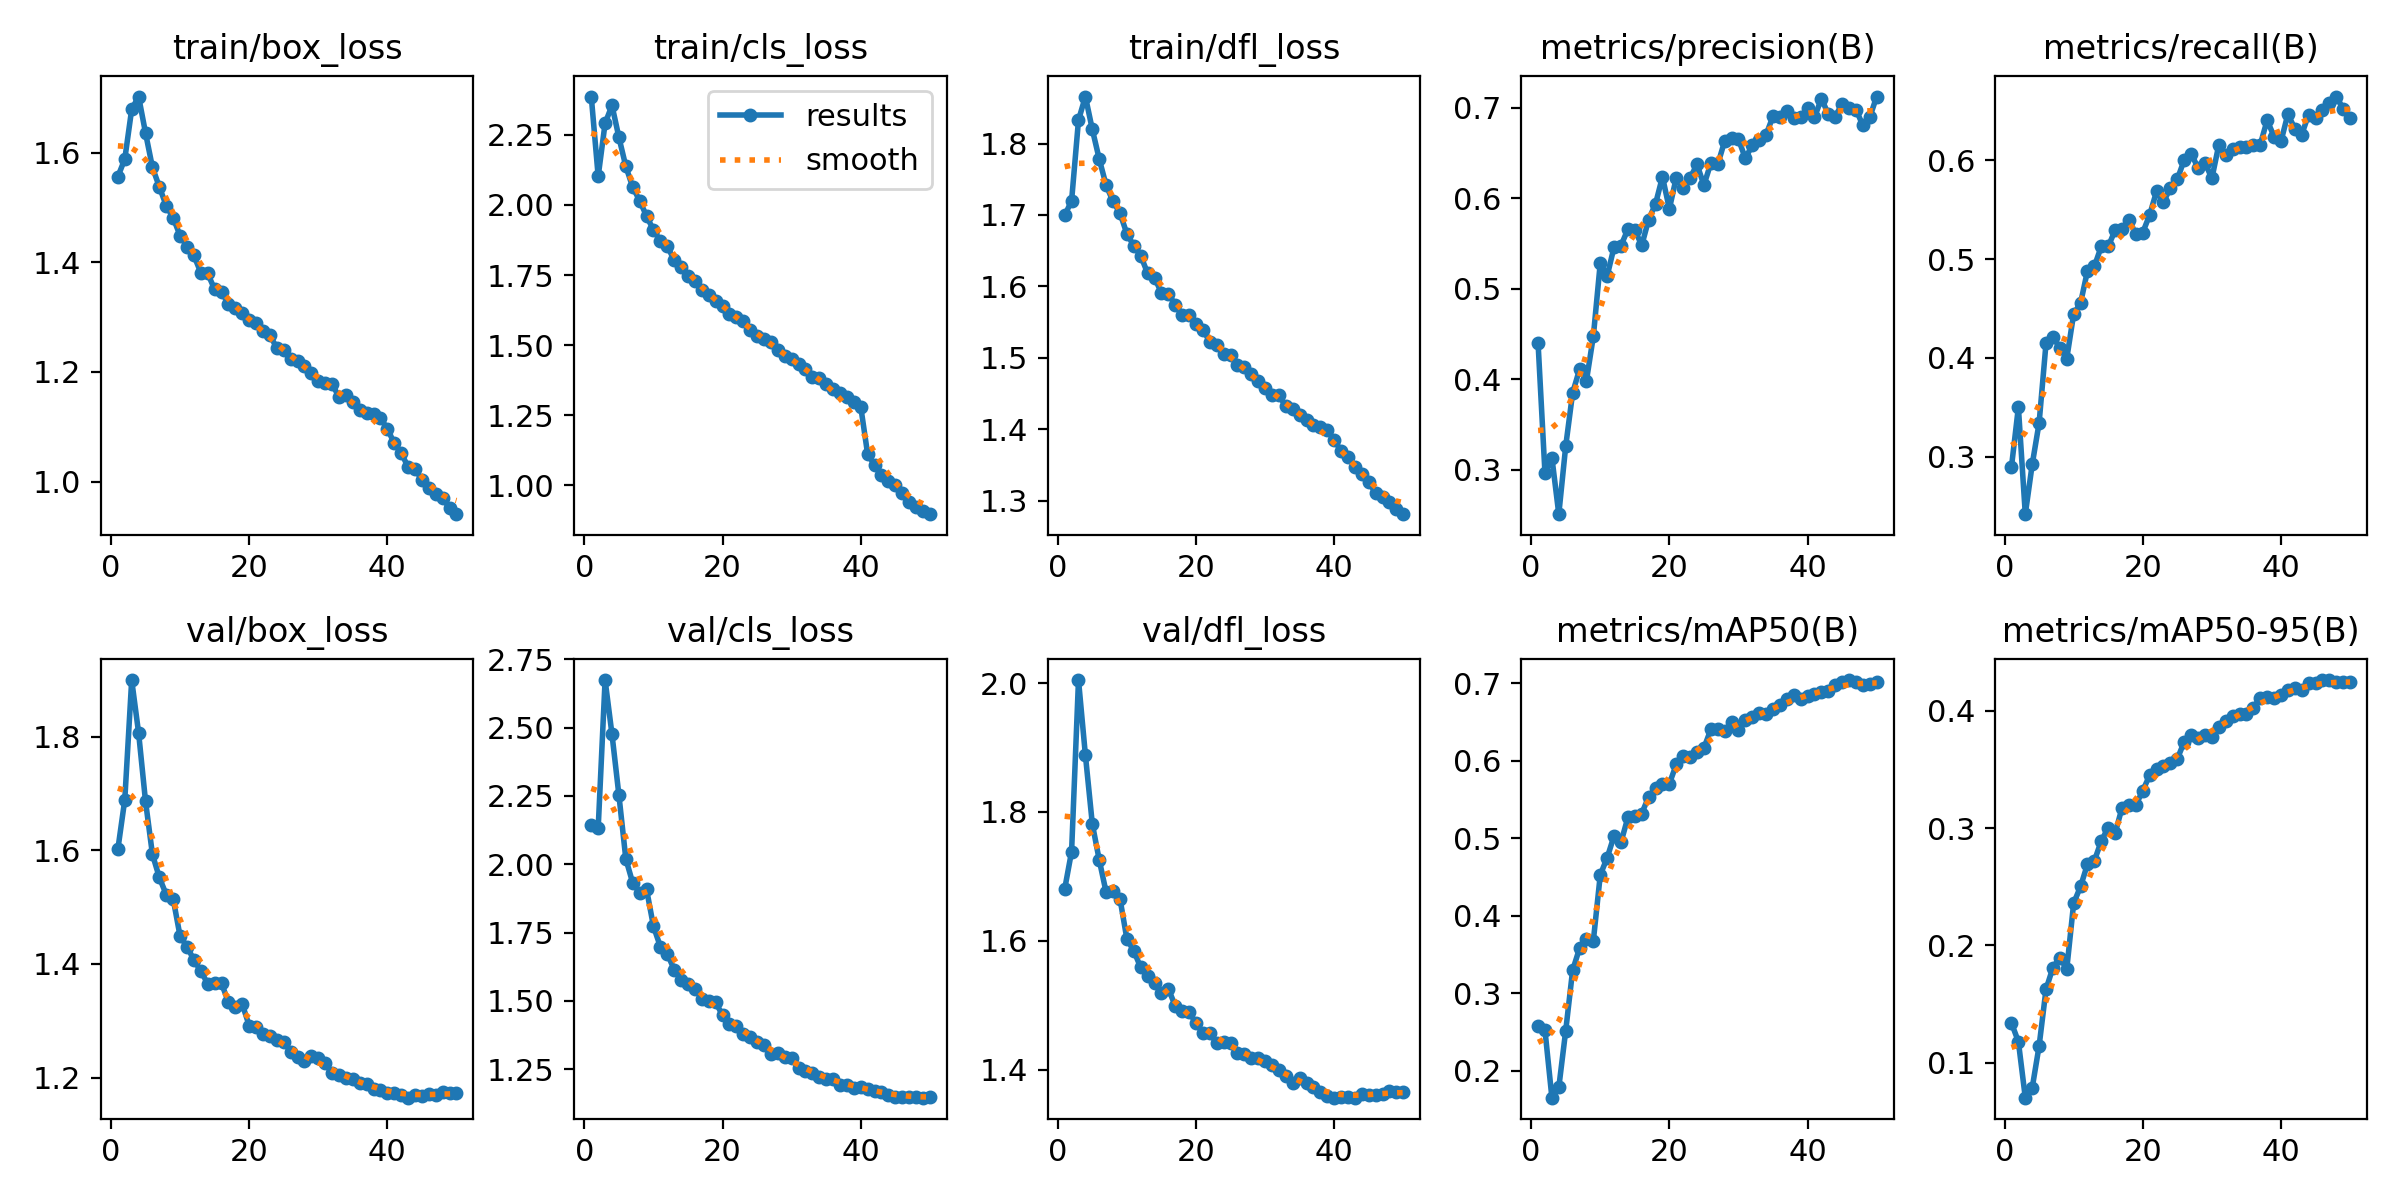


📉 CONFUSION MATRIX 📉


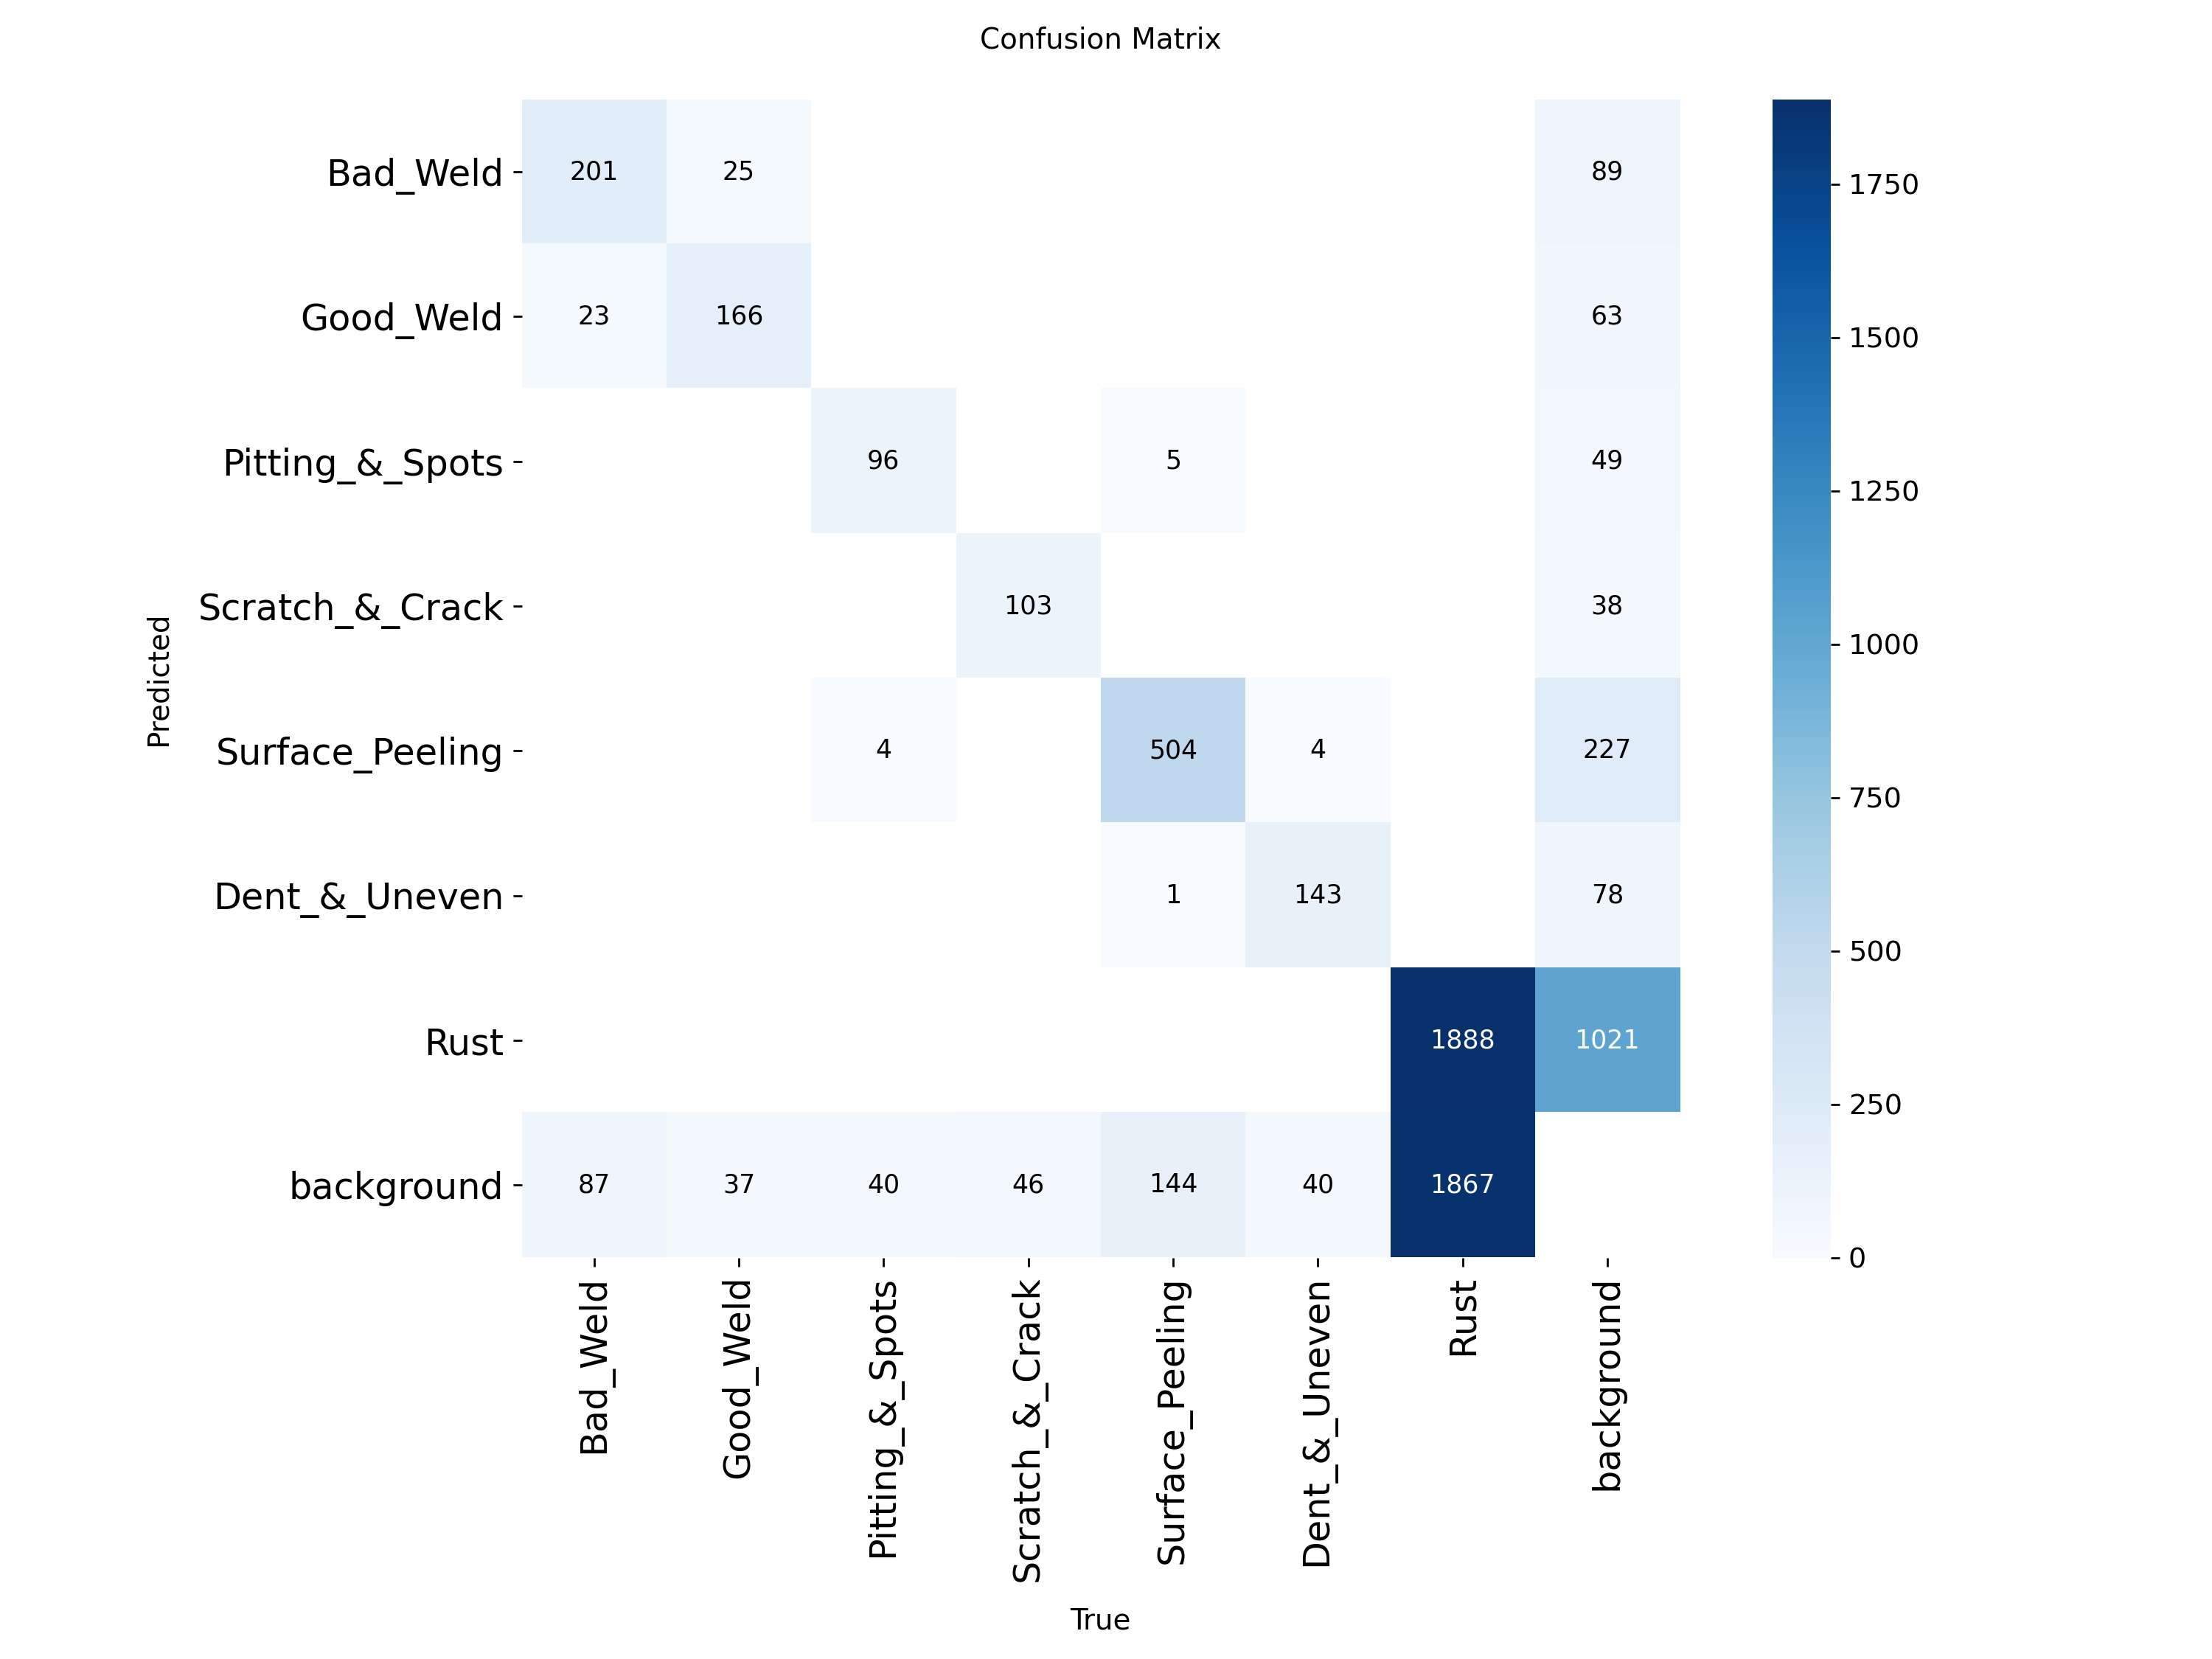

In [4]:
from IPython.display import Image, display

# Display the final performance graph automatically generated by YOLO
print("📊 FINAL TRAINING PERFORMANCE GRAPHS 📊")
display(Image(filename='/kaggle/working/yolo_weld_model/results.png', width=1000))

# Display Confusion Matrix to check class-wise errors
print("\n📉 CONFUSION MATRIX 📉")
display(Image(filename='/kaggle/working/yolo_weld_model/confusion_matrix.png', width=1000))